## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [1]:
!pip install folium

'pip' is not recognized as an internal or external command,
operable program or batch file.


### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [2]:
import numpy as np
import pandas as pd

In [3]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [4]:
customer_data.info()

<class 'pandas.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   str    
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16  N

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [5]:
customer_data['Income'] = customer_data['Income'].fillna(customer_data['Income'].mean())
print('Missing Income after imputation:', customer_data['Income'].isna().sum())

Missing Income after imputation: 0


#### A3. Feature engineering

In [6]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [7]:
customer_data['Age'] = 2022 - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [8]:
# Convert the date column before subtracting it from today's date.
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], dayfirst=True)
customer_data['Enroll_days'] = (pd.Timestamp.now().normalize() - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [9]:
marital_map = {
    'Absurd': 1, 'Alone': 1, 'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2, 'Widow': 1, 'Divorced': 1
}
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map)
customer_data['Fam_Size'] = customer_data['Marital_Status'] + customer_data['Kidhome'] + customer_data['Teenhome']

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [10]:
customer_data['Num_Accepted'] = customer_data[[f'AcceptedCmp{i}' for i in range(1, 6)]].sum(axis=1)

In [11]:
customer_data['MntTotal'] = customer_data[[c for c in customer_data.columns if c.startswith('Mnt')]].sum(axis=1)

#### A4. Phân tích EDA

In [12]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4835.582143,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4482.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4662.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4837.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5011.000000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5181.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.906959,0.678381,602.249288


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

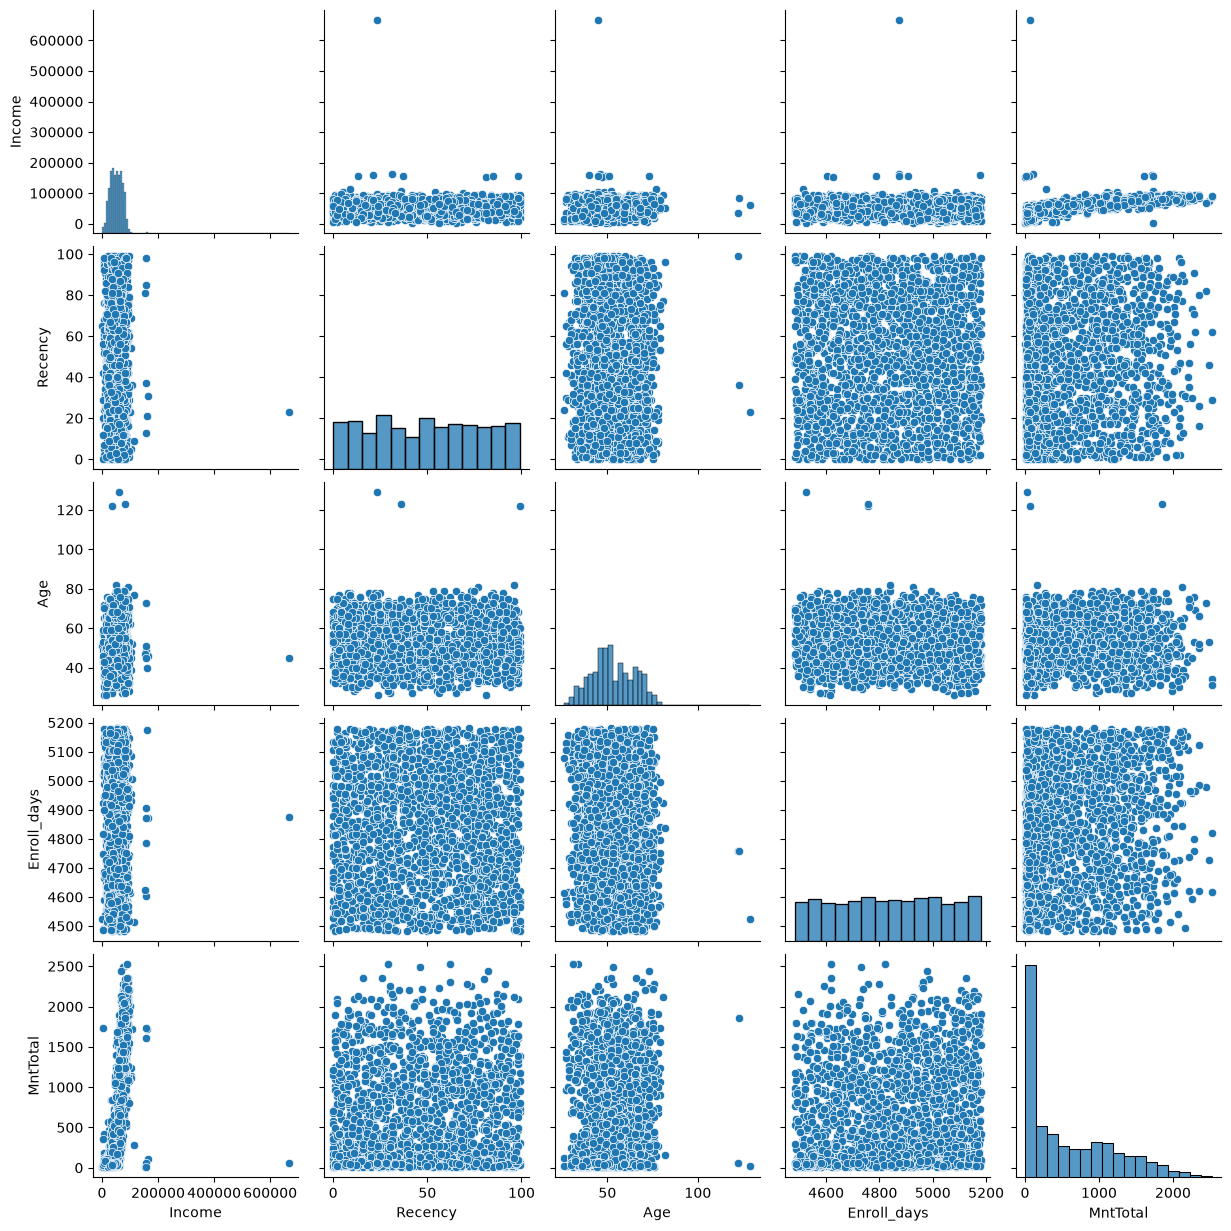

In [14]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
sns.pairplot(customer_data[plot_cols].dropna(), diag_kind='hist')
plt.show()

In [15]:
# Cap numeric outliers at 1.5 IQR so a few extreme values do not dominate Euclidean distance.
for col in customer_data.select_dtypes(include='number').columns:
    q1, q3 = customer_data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    customer_data[col] = customer_data[col].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

In [16]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df = df.select_dtypes(include='number')

**Chuẩn hoá các thuộc tính kiểu số**

In [18]:
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

In [19]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03
mean,2.252167e-16,-3.172066e-18,-1.300547e-16,-8.247371e-17,-6.978545e-17,7.612958e-17,-1.808077e-16,-2.164935e-16,1.419499e-15,-1.173664e-16,-1.046782e-16
std,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00
min,-2.395690e+00,-1.696001e+00,-1.440281e+00,-1.534231e+00,-9.597465e-01,-1.781466e+00,-2.257020e+00,-2.306699e+00,-1.749736e+00,-1.785029e+00,-9.978811e-01
25%,-7.804731e-01,-8.671566e-01,-7.902250e-01,-7.785853e-01,-9.597465e-01,-8.584551e-01,-9.792464e-01,-6.923019e-01,-8.552770e-01,-6.609175e-01,-8.919937e-01
50%,-6.385164e-03,-3.777284e-03,-1.401684e-01,-2.293925e-02,-2.282623e-01,-2.431145e-01,2.985275e-01,-9.752387e-02,9.490706e-03,4.631943e-01,-3.484389e-01
75%,7.842091e-01,8.596020e-01,5.098881e-01,7.327068e-01,5.032220e-01,6.798964e-01,7.244522e-01,8.371273e-01,8.680727e-01,4.631943e-01,7.303660e-01
max,3.131233e+00,1.722981e+00,2.460058e+00,2.999645e+00,2.697675e+00,2.218248e+00,3.280000e+00,3.131271e+00,1.709335e+00,2.149362e+00,3.163906e+00


#### A6. Phân cụm KMeans

In [20]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

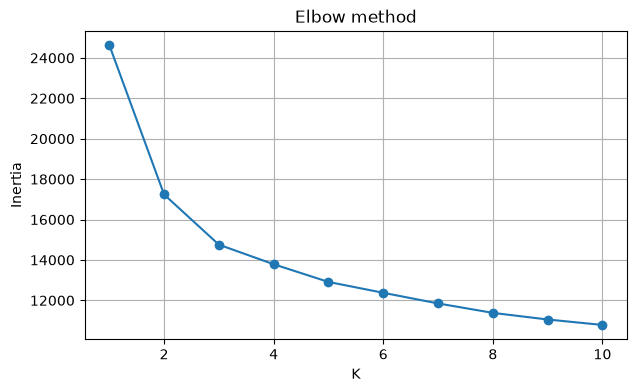

In [21]:
inertias = []
ks = range(1, 11)
for k in ks:
    model = KMeans(n_clusters=k, n_init=10, random_state=99)
    model.fit(df)
    inertias.append(model.inertia_)
plt.figure(figsize=(7, 4))
plt.plot(ks, inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.grid(True)
plt.show()

Sử dụng thư viện yellowbrick

In [22]:
# Elbow selection is plotted directly with KMeans inertia below.

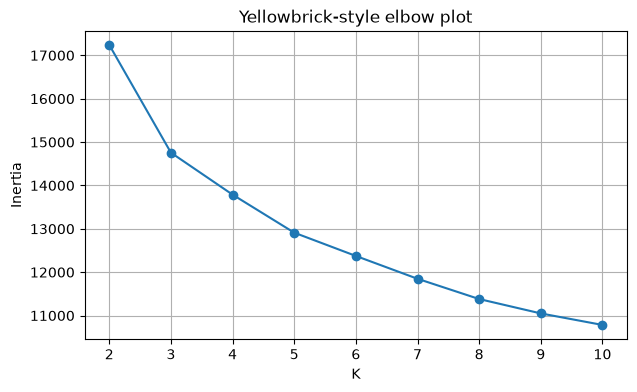

In [23]:
ks = range(2, 11)
inertias = []
for k in ks:
    model = KMeans(n_clusters=k, n_init=20, random_state=99)
    model.fit(df)
    inertias.append(model.inertia_)
plt.figure(figsize=(7, 4))
plt.plot(ks, inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Yellowbrick-style elbow plot')
plt.grid(True)
plt.show()

**Phân cụm từ kết quả của phương pháp Elbow**

In [24]:
kmean = KMeans(n_clusters=4, n_init=20, random_state=99).fit(df)
print('Cluster counts:', np.unique(kmean.labels_, return_counts=True))

Cluster counts: (array([0, 1, 2, 3], dtype=int32), array([511, 682, 472, 575]))


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [25]:
from sklearn.decomposition import PCA

In [26]:
pca = PCA()
pca_transformed = pca.fit_transform(df)

**Trực quan hoá kết quả phân cụm**

In [27]:
def visualize_cluster_result(scores, labels):
    """Plot data projected into two PCA dimensions and colored by cluster."""
    fig1, axes = plt.subplots(figsize=(8, 8))
    sns.scatterplot(x=scores[:, 0], y=scores[:, 1], hue=labels, ax=axes,
                    palette='Set1', legend='full')
    axes.set_xlabel('PC1')
    axes.set_ylabel('PC2')
    axes.grid(True)
    plt.show()

#### Phân tích kết quả phân cụm (KMeans)

In [28]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,81,546,120.5,81,88.0,3,8,10,4,7,0,0,0,0,0,0,3,11,0,65,5145,1.0,0,1617.0,1
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2.0,1,6.0,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4595,3.0,0,27.0,2
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111.0,21,42.0,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4794,2.0,0,776.0,1
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10.0,3,5.0,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4621,3.0,0,53.0,3
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46.0,27,15.0,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4643,3.0,0,422.0,0


In [29]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

In [30]:
# visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

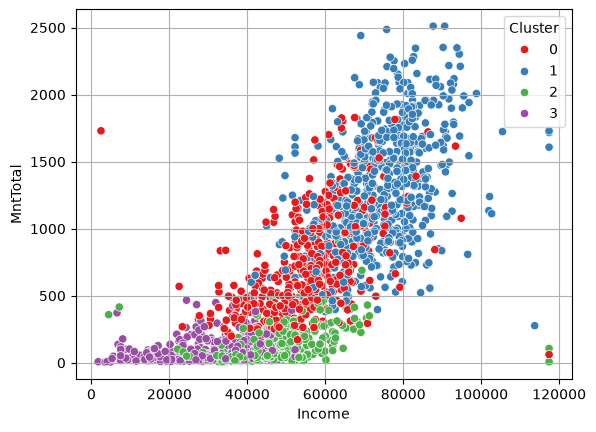

In [31]:
sns.scatterplot(data=kmean_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.grid(True)
plt.show()

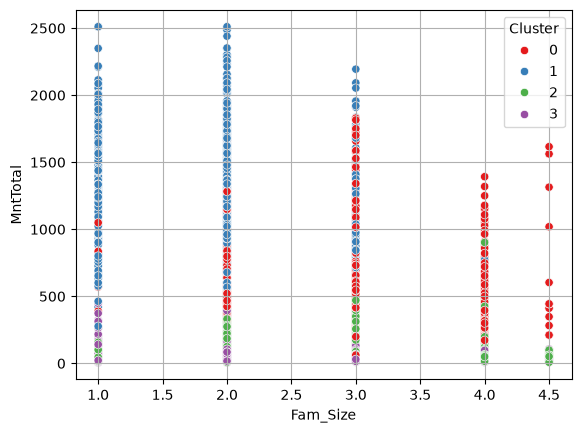

In [32]:
sns.scatterplot(data=kmean_df, x='Fam_Size', y='MntTotal', hue='Cluster', palette='Set1')
plt.grid(True)
plt.show()

**Phân tích danh mục mua hàng**

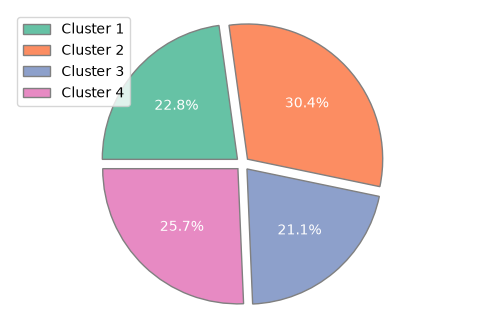

In [33]:
visualize_cluster_distribution(kmean.labels_)

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [34]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

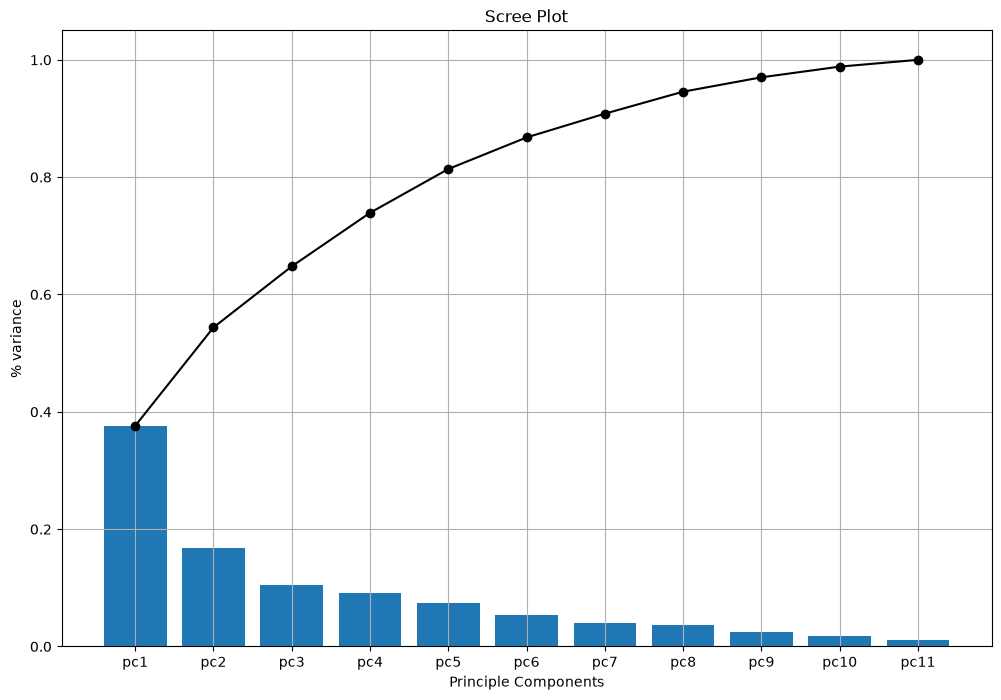

In [35]:
scree_plot(pca, [f'pc{i+1}' for i in range(len(df.columns))])

In [36]:
pca_4d = PCA(n_components=4, random_state=99)
pca_transformed_4d = pca_4d.fit_transform(df)

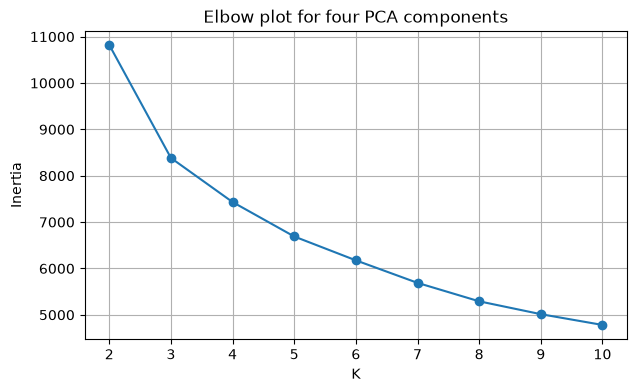

In [37]:
ks_pca = range(2, 11)
inertias_pca = []
for k in ks_pca:
    model = KMeans(n_clusters=k, n_init=20, random_state=99)
    model.fit(pca_transformed_4d)
    inertias_pca.append(model.inertia_)
plt.figure(figsize=(7, 4))
plt.plot(ks_pca, inertias_pca, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow plot for four PCA components')
plt.grid(True)
plt.show()
kmean_pca = KMeans(n_clusters=4, n_init=20, random_state=99).fit(pca_transformed_4d)

In [38]:
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean_pca.labels_
kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,81,546,120.5,81,88.0,3,8,10,4,7,0,0,0,0,0,0,3,11,0,65,5145,1.0,0,1617.0,1
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2.0,1,6.0,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4595,3.0,0,27.0,3
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111.0,21,42.0,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4794,2.0,0,776.0,1
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10.0,3,5.0,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4621,3.0,0,53.0,2
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46.0,27,15.0,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4643,3.0,0,422.0,0


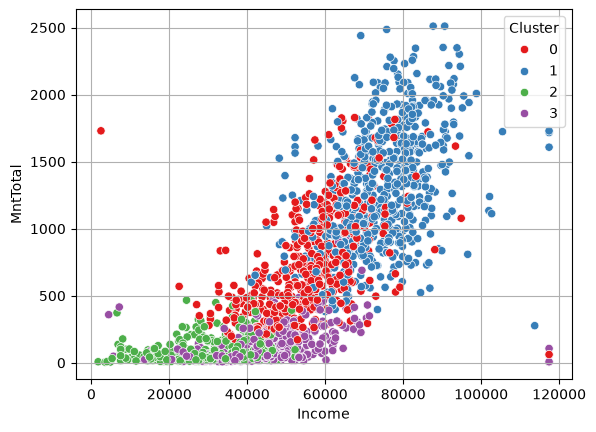

In [39]:
sns.scatterplot(data=kmean_pca_df, x='Income', y='MntTotal', hue='Cluster', palette='Set1')
plt.grid(True)
plt.show()

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [40]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [41]:
len(df.columns)

11

In [42]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)
    
    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [43]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

### B. Dữ liệu taxi 

In [44]:
import pandas as pd

In [45]:
df = pd.read_csv('data/taxi_data.csv').dropna(subset=['LAT', 'LON']).copy()
df.head()

,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [46]:
import folium, re

In [47]:
X = df[['LAT', 'LON']].to_numpy(dtype=float)
m = folium.Map(location=[X[:, 0].mean(), X[:, 1].mean()], tiles='OpenStreetMap', zoom_start=10)

In [48]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

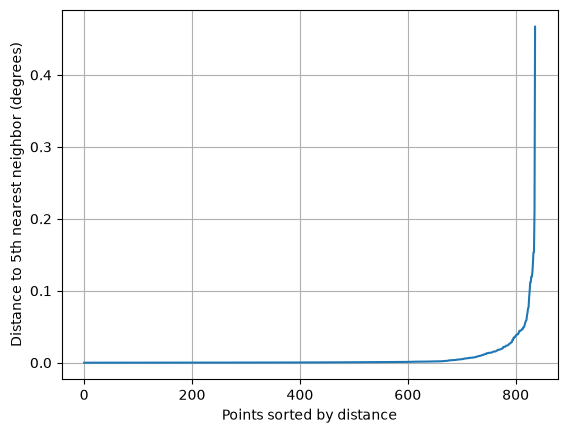

In [49]:
distances = knee_plot(5, X)
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to 5th nearest neighbor (degrees)')
plt.grid(True)
plt.show()

In [50]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [51]:
dbscan = DBSCAN(eps=0.005, min_samples=5)
df['Cluster'] = dbscan.fit_predict(X)
cluster_ids = sorted(df['Cluster'].unique())
color_map = {cluster: ('black' if cluster == -1 else colors[i % len(colors)])
             for i, cluster in enumerate(cluster_ids)}
df['Color'] = df['Cluster'].map(color_map)
print('Cluster counts:', df['Cluster'].value_counts().sort_index().to_dict())

Cluster counts: {-1: 344, 0: 8, 1: 6, 2: 7, 3: 9, 4: 12, 5: 9, 6: 6, 7: 6, 8: 13, 9: 7, 10: 9, 11: 59, 12: 10, 13: 7, 14: 8, 15: 5, 16: 5, 17: 10, 18: 8, 19: 9, 20: 7, 21: 7, 22: 6, 23: 6, 24: 7, 25: 7, 26: 7, 27: 15, 28: 21, 29: 14, 30: 18, 31: 10, 32: 7, 33: 14, 34: 6, 35: 10, 36: 26, 37: 8, 38: 5, 39: 12, 40: 7, 41: 8, 42: 7, 43: 8, 44: 5, 45: 12, 46: 5, 47: 5, 48: 10}


In [52]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='OpenStreetMap',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=row[cluster_column],
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m